# Track B: Laptop Price Regression — Startech.com.bd

**Target**: `Price_BDT` (BDT)  \n
**Source**: Scraped from [startech.com.bd](https://www.startech.com.bd/laptop-notebook/laptop)  
**Pipeline**: Data Cleaning → EDA → Feature Engineering → Modeling → Evaluation  
**Global seed**: `random_state=42`

## 1. Data Cleaning

### 1.1 Load raw scraped data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import re, warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
np.random.seed(42)

RANDOM_STATE = 42
RAW_PATH  = "../data/track_b/raw/track_b_listings.csv"
CLEANED_PATH = "../data/track_b/cleaned/laptop_listings_cleaned.csv"

df_raw = pd.read_csv(RAW_PATH, encoding='utf-8-sig')
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (472, 11)


,Brand,Model,Processor,RAM,Storage,Display,GPU,Price_BDT,Availability,Source,Product_URL
0,Smart,Smart Flairedge 13th Gen Intel Core i5 1335U 8...,Intel Core i5,8GB,512GB SSD,"15.6""",Intel Iris Xe Graphics,64500.0,In Stock,ryans.com,https://www.ryans.com/smart-flairedge-13th-gen...
1,Smart,Smart Flairedge Intel Core i7 1255U 8GB RAM 51...,Intel Core i7,8GB,512GB SSD,"16""",Intel Iris Xe Graphics,68500.0,In Stock,ryans.com,https://www.ryans.com/smart-flairedge-intel-co...
2,Tecno,TECNO Megabook T14 Air Intel Core i5 1334U 16G...,Intel Core i5,16GB,512GB SSD,"14""",Intel Iris Xe Graphics,71900.0,In Stock,ryans.com,https://www.ryans.com/tecno-megabook-t14-air-i...


### 1.2 Data Dictionary

In [2]:
dtypes = df_raw.dtypes.astype(str)
missing_ct = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().mean() * 100).round(1)
nunique = df_raw.nunique()
dict_df = pd.DataFrame({
    "Dtype": dtypes, "Missing": missing_ct,
    "Missing%": missing_pct, "Unique": nunique
})
dict_df

,Dtype,Missing,Missing%,Unique
Brand,str,0,0.0,14
Model,str,0,0.0,471
Processor,str,6,1.3,164
RAM,str,3,0.6,93
Storage,str,1,0.2,60
Display,str,25,5.3,137
GPU,str,27,5.7,209
Price_BDT,float64,49,10.4,210
Availability,str,0,0.0,2
Source,str,0,0.0,2


### 1.3 Strip Taka symbol and clean price

In [3]:
df = df_raw.copy()
# Price_BDT is already numeric from the scraper (float64)
# Check for NaN prices (out-of-stock items)
print(f"Price_BDT missing: {df['Price_BDT'].isna().sum()} out of {len(df)}")
print("Rows with missing price:")
missing_prices = df[df['Price_BDT'].isna()]
if len(missing_prices) > 0:
    print(missing_prices[["Model", "Price_BDT", "Availability"]].head(10).to_string())
print("Decision: Rows with non-numeric Price (Out of Stock) will be dropped — cannot use as target.")

Price_BDT missing: 49 out of 472
Rows with missing price:
                                                                                                  Model  Price_BDT  Availability
258                                     Chuwi GemiBook XPro Intel Celeron N100 14.1 inch Full HD Laptop        NaN  Out of Stock
284                                     Lenovo IdeaPad Slim 5 13ARP10 Ryzen 7 7735HS 13.3" WUXGA Laptop        NaN  Out of Stock
297                                       Acer Aspire 3 A325-53 Core i5 13th Gen 1334U 15.6" FHD Laptop        NaN  Out of Stock
300  Lenovo IdeaPad Slim 3 15IRH8 Core i5 13th Gen 8GB RAM 15.6" FHD Military Grade Laptop With FreeDOS        NaN  Out of Stock
305                      Acer ALG AL15G-53 Core i5 13420H RTX 3050 6GB Graphics 15.6" FHD Gaming Laptop        NaN  Out of Stock
314                                                         HP 15-fd0333TU Core 5 120U 15.6" FHD Laptop        NaN  Out of Stock
324                                  Ac

### 1.4 Deduplicate listings

In [4]:
before = len(df)
df = df.drop_duplicates(subset=["Product_URL"], keep="first")
print(f"Dedup: {before} \u2192 {len(df)} rows")

Dedup: 472 → 472 rows


### 1.5 Parse RAM \u2192 GB

In [5]:
def parse_ram_gb(text):
    if pd.isna(text): return np.nan
    text = str(text)
    match = re.search(r'(\d+)\s*GB', text, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'(\d+)\s*MB', text, re.IGNORECASE)
    if match: return int(match.group(1)) // 1024
    return np.nan

df["RAM_GB"] = df["RAM"].apply(parse_ram_gb)
print(f"RAM missing after parse: {df['RAM_GB'].isna().sum()} / {len(df)}")

RAM missing after parse: 3 / 472


### 1.6 Parse Storage \u2192 SSD_GB, HDD_GB

In [6]:
def parse_storage(text):
    if pd.isna(text): return (0, 0)
    text = str(text)
    if "storage:" in text.lower():
        text = text.lower().split("storage:")[1].strip()
    ssd, hdd = 0.0, 0.0
    def _to_gb(part):
        nums = re.findall(r'[\d.]+', part)
        if not nums: return 0.0
        val = float(nums[-1])
        if "tb" in part.lower(): val *= 1024
        return val
    lower = text.lower()
    if "ssd" in lower:
        ssd = _to_gb(text[:text.lower().index("ssd")])
    if "hdd" in lower:
        hdd = _to_gb(text[:text.lower().index("hdd")])
    if ssd == 0 and hdd == 0:
        total = _to_gb(text)
        if total > 0: ssd = total
    return (int(round(ssd)), int(round(hdd)))

storage_parsed = df["Storage"].apply(parse_storage)
df["SSD_GB"] = storage_parsed.apply(lambda x: x[0])
df["HDD_GB"] = storage_parsed.apply(lambda x: x[1])
df["Total_Storage_GB"] = df["SSD_GB"] + df["HDD_GB"]
print("Storage parsing samples:")
print(df[["Storage", "SSD_GB", "HDD_GB"]].head(10))

Storage parsing samples:
     Storage  SSD_GB  HDD_GB
0  512GB SSD     512       0
1  512GB SSD     512       0
2  512GB SSD     512       0
3  512GB SSD     512       0
4  512GB SSD     512       0
5  512GB SSD     512       0
6  512GB SSD     512       0
7  512GB SSD     512       0
8  512GB SSD     512       0
9  512GB SSD     512       0


### 1.7 Parse Processor \u2192 brand + GHz

In [7]:
def parse_processor(text):
    if pd.isna(text): return ("Other", 0.0)
    lower = str(text).lower()
    if "intel" in lower: brand = "Intel"
    elif "amd" in lower or "ryzen" in lower: brand = "AMD"
    elif "apple" in lower or "m1" in lower or "m2" in lower: brand = "Apple"
    elif "qualcomm" in lower or "snapdragon" in lower: brand = "Qualcomm"
    elif "mediatek" in lower: brand = "MediaTek"
    else: brand = "Other"
    ghz_match = re.search(r'([\d.]+)\s*ghz', lower)
    ghz = float(ghz_match.group(1)) if ghz_match else 0.0
    return (brand, ghz)

proc_parsed = df["Processor"].apply(parse_processor)
df["CPU_Brand"] = proc_parsed.apply(lambda x: x[0])
df["CPU_GHz"] = proc_parsed.apply(lambda x: x[1])
print("CPU brand distribution:")
print(df["CPU_Brand"].value_counts())

CPU brand distribution:
CPU_Brand
Intel       281
AMD         114
Qualcomm     31
Apple        27
Other        19
Name: count, dtype: int64


### 1.8 Parse Display \u2192 size + resolution + PPI

In [8]:
def parse_display(text):
    if pd.isna(text): return (np.nan, 0, 0, False)
    text = str(text)
    size_match = re.search(r'([\d.]+)\s*"?\s*(?:inch|\u201d|")', text, re.IGNORECASE)
    size = float(size_match.group(1)) if size_match else np.nan
    res_match = re.search(r'(\d+)\s*x\s*(\d+)', text, re.IGNORECASE)
    width = int(res_match.group(1)) if res_match else 0
    height = int(res_match.group(2)) if res_match else 0
    is_touch = "touch" in text.lower()
    return (size, width, height, is_touch)

disp_parsed = df["Display"].apply(parse_display)
df["Screen_Size"] = disp_parsed.apply(lambda x: x[0])
df["Screen_Width"] = disp_parsed.apply(lambda x: x[1])
df["Screen_Height"] = disp_parsed.apply(lambda x: x[2])
df["Is_Touchscreen"] = disp_parsed.apply(lambda x: x[3])
df["PPI"] = np.sqrt(df["Screen_Width"]**2 + df["Screen_Height"]**2) / df["Screen_Size"]

print("Display parsing samples:")
print(df[["Display", "Screen_Size", "Screen_Width", "Screen_Height", "PPI"]].head(10))

Display parsing samples:
  Display  Screen_Size  Screen_Width  Screen_Height  PPI
0   15.6"         15.6             0              0  0.0
1     16"         16.0             0              0  0.0
2     14"         14.0             0              0  0.0
3   15.6"         15.6             0              0  0.0
4   15.6"         15.6             0              0  0.0
5   15.6"         15.6             0              0  0.0
6   15.6"         15.6             0              0  0.0
7   15.6"         15.6             0              0  0.0
8   15.6"         15.6             0              0  0.0
9   15.6"         15.6             0              0  0.0


### 1.9 Parse GPU brand

In [9]:
def parse_gpu_brand(text):
    if pd.isna(text): return "Unknown"
    lower = text.lower()
    if "nvidia" in lower: return "Nvidia"
    elif "amd" in lower or "radeon" in lower: return "AMD"
    elif "intel" in lower: return "Intel"
    elif "apple" in lower or "m" in lower: return "Apple"
    elif "qualcomm" in lower or "adreno" in lower: return "Qualcomm"
    else: return "Other"
df["GPU_Brand"] = df["GPU"].apply(parse_gpu_brand)
print("GPU brand distribution:")
print(df["GPU_Brand"].value_counts())

GPU brand distribution:
GPU_Brand
Intel      199
Nvidia      96
AMD         81
Apple       59
Unknown     27
Other       10
Name: count, dtype: int64


### 1.10 Handle missing values — documented strategy

In [10]:
print("Missing values before treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
print()

df["GPU_Brand"] = df["GPU_Brand"].fillna("Unknown")

ram_med = df["RAM_GB"].median()
df["RAM_GB"].fillna(ram_med, inplace=True)
print(f"RAM_GB: median imputed ({ram_med:.0f} GB)")

size_med = df["Screen_Size"].median()
df["Screen_Size"].fillna(size_med, inplace=True)
print(f"Screen_Size: median imputed ({size_med:.1f} in)")

df["PPI"] = np.sqrt(df["Screen_Width"]**2 + df["Screen_Height"]**2) / df["Screen_Size"]
ppi_med = df["PPI"].median()
df["PPI"].fillna(ppi_med, inplace=True)
print(f"PPI: median imputed ({ppi_med:.1f})")
# Handle inf PPI
df["PPI"].replace([np.inf, -np.inf], ppi_med, inplace=True)

ghz_med = df["CPU_GHz"].median()
df["CPU_GHz"].fillna(ghz_med, inplace=True)
print(f"CPU_GHz: median imputed ({ghz_med:.2f} GHz)")

# Drop rows with missing Price_BDT (cannot model without target)
price_missing = df["Price_BDT"].isna().sum()
df.dropna(subset=["Price_BDT"], inplace=True)
print(f"Price_BDT: dropped {price_missing} rows (no valid target)")

Missing values before treatment:
Processor       6
RAM             3
Storage         1
Display        25
GPU            27
Price_BDT      49
RAM_GB          3
Screen_Size    52
PPI            52

RAM_GB: median imputed (16 GB)
Screen_Size: median imputed (15.1 in)
PPI: median imputed (0.0)
CPU_GHz: median imputed (0.00 GHz)
Price_BDT: dropped 49 rows (no valid target)


### 1.11 Outlier detection — Price_BDT

In [11]:
q1, q3 = df["Price_BDT"].quantile(0.25), df["Price_BDT"].quantile(0.75)
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr
z = np.abs(stats.zscore(df["Price_BDT"]))
print(f"Price_BDT: mean={df['Price_BDT'].mean():.0f}, std={df['Price_BDT'].std():.0f}")
print(f"IQR upper bound: {upper_iqr:.0f}, outliers above: {(df['Price_BDT'] > upper_iqr).sum()}")
print(f"Z>3 outliers: {(z > 3).sum()}")
print("Decision: RETAIN — outliers are genuine high-end gaming laptops (RTX 5090 configs)")

Price_BDT: mean=166601, std=116917
IQR upper bound: 336750, outliers above: 32
Z>3 outliers: 11
Decision: RETAIN — outliers are genuine high-end gaming laptops (RTX 5090 configs)


### 1.12 Save cleaned dataset

In [12]:
cols_to_drop = ["Model", "RAM", "Storage", "Display", "Processor", "GPU", "Product_URL", "Source"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved to {CLEANED_PATH}")
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved to ../data/track_b/cleaned/laptop_listings_cleaned.csv
Final shape: (423, 15)
Columns: ['Brand', 'Price_BDT', 'Availability', 'RAM_GB', 'SSD_GB', 'HDD_GB', 'Total_Storage_GB', 'CPU_Brand', 'CPU_GHz', 'Screen_Size', 'Screen_Width', 'Screen_Height', 'Is_Touchscreen', 'PPI', 'GPU_Brand']


## 2. Exploratory Data Analysis

### 2.1 Univariate — Target

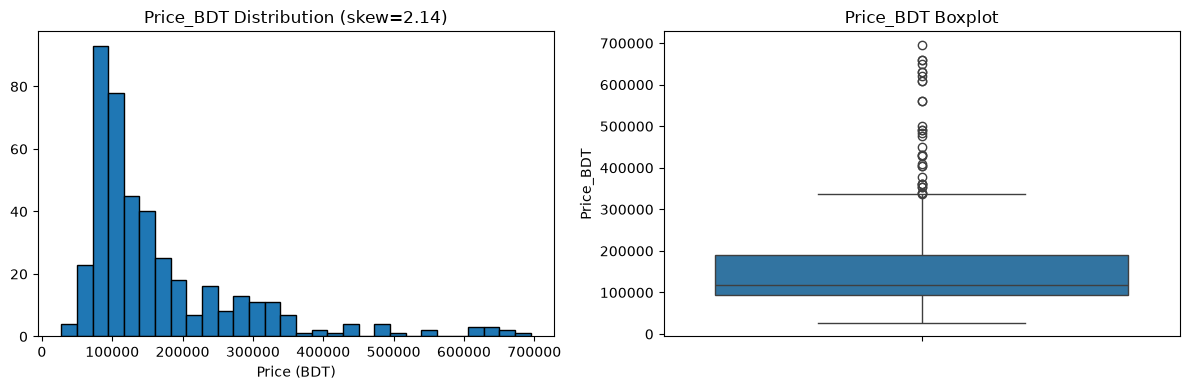

Price is right-skewed with a handful of high-end gaming laptops above 400,000 BDT.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Price_BDT"], bins=30, edgecolor="black")
axes[0].set_title(f"Price_BDT Distribution (skew={df['Price_BDT'].skew():.2f})")
axes[0].set_xlabel("Price (BDT)")
sns.boxplot(y=df["Price_BDT"], ax=axes[1])
axes[1].set_title("Price_BDT Boxplot")
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/price_distribution.png", dpi=100)
plt.show()
print("Price is right-skewed with a handful of high-end gaming laptops above 400,000 BDT.")

### 2.2 Univariate — Numeric features

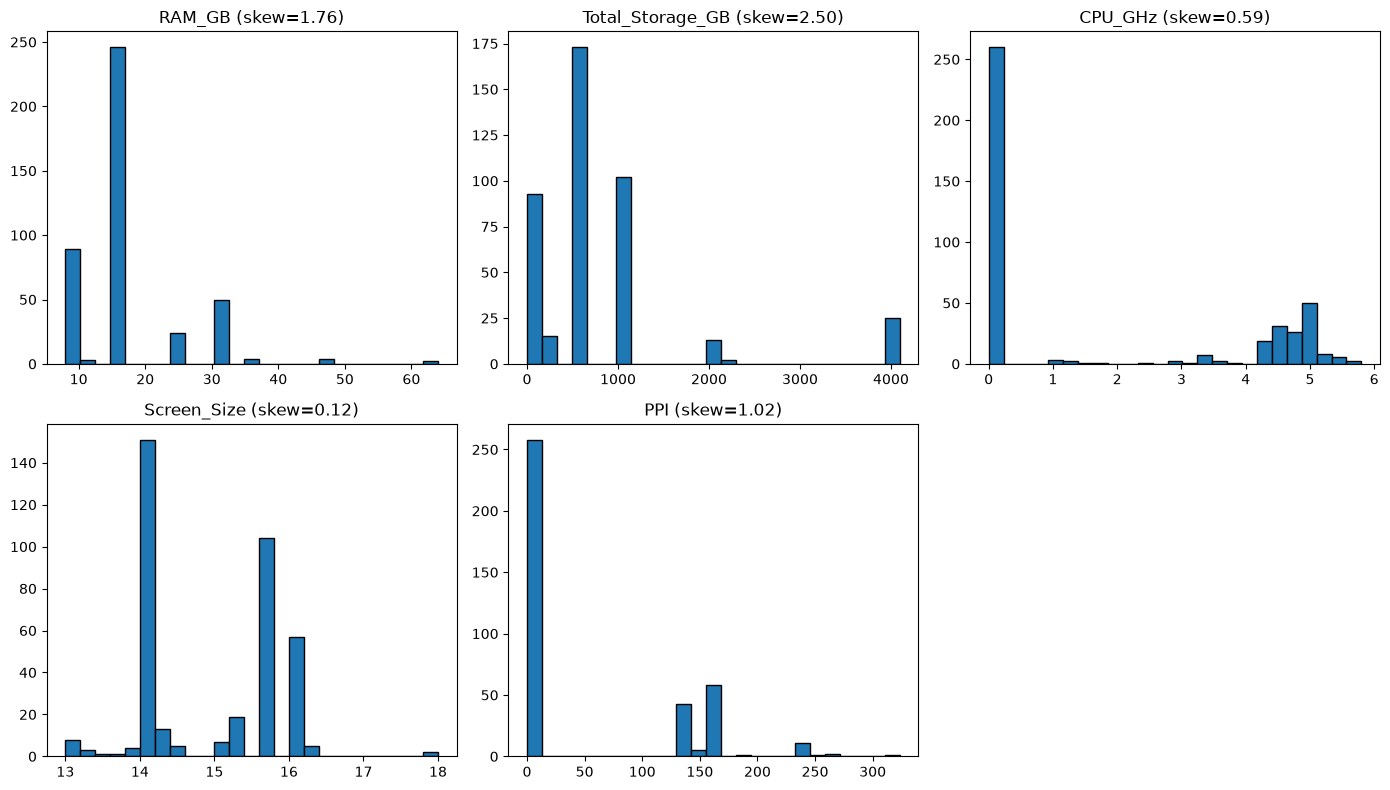

In [14]:
num_cols = ["RAM_GB", "Total_Storage_GB", "CPU_GHz", "Screen_Size", "PPI"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, edgecolor="black")
        axes[i].set_title(f"{col} (skew={df[col].skew():.2f})")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/numeric_distributions.png", dpi=100)
plt.show()

### 2.3 Bivariate — Price vs Numeric

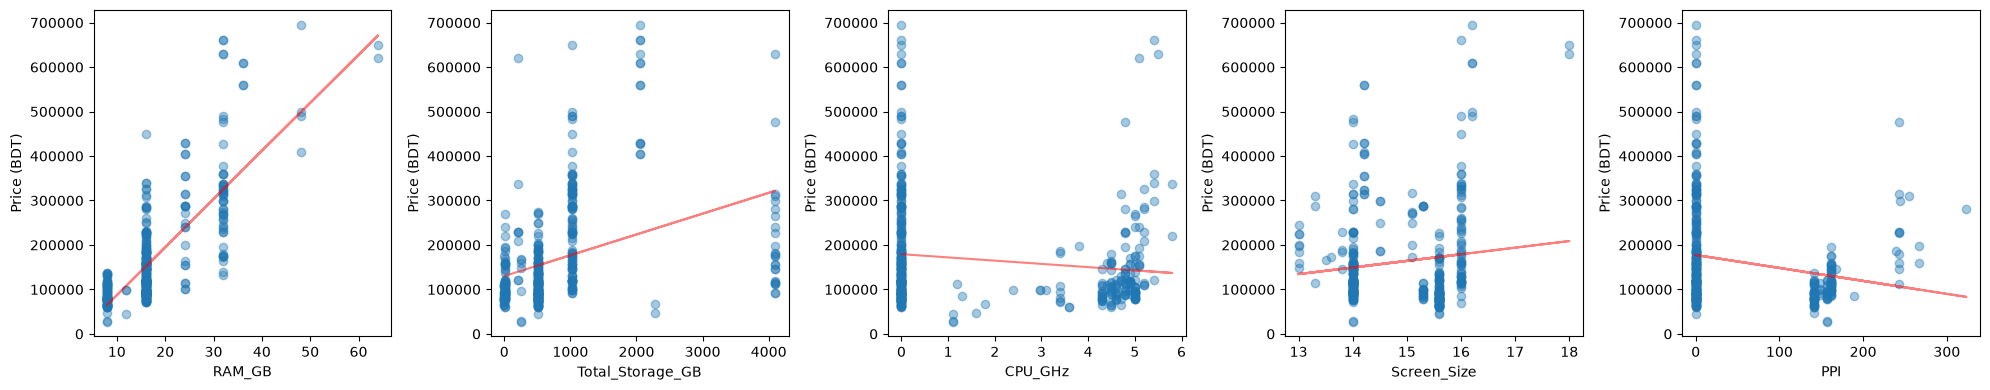

In [15]:
scatter_cols = ["RAM_GB", "Total_Storage_GB", "CPU_GHz", "Screen_Size", "PPI"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(scatter_cols):
    if col in df.columns:
        axes[i].scatter(df[col], df["Price_BDT"], alpha=0.4)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Price (BDT)")
        # Add trend line
        mask = df[col].notna()
        if mask.sum() > 1:
            m, b = np.polyfit(df.loc[mask, col], df.loc[mask, "Price_BDT"], 1)
            axes[i].plot(df[col], m*df[col]+b, "r-", alpha=0.5)
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/scatter_matrix.png", dpi=100)
plt.show()

### 2.4 Bivariate — Price by Category

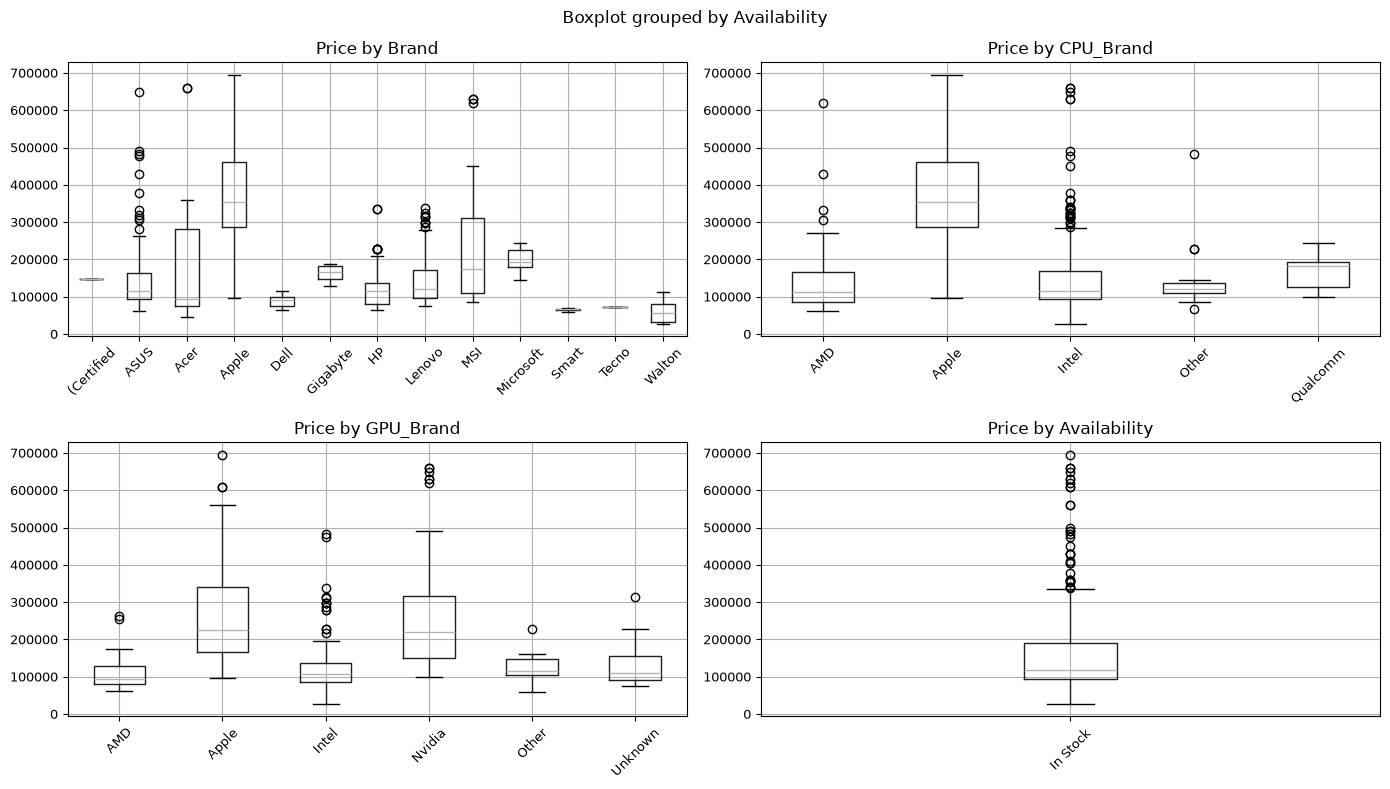

In [16]:
cat_cols = ["Brand", "CPU_Brand", "GPU_Brand", "Availability"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col in df.columns:
        df.boxplot(column="Price_BDT", by=col, ax=axes[i], rot=45, fontsize=9)
        axes[i].set_title(f"Price by {col}")
        axes[i].set_xlabel("")
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/category_boxplots.png", dpi=100)
plt.show()

### 2.5 Correlation Heatmap

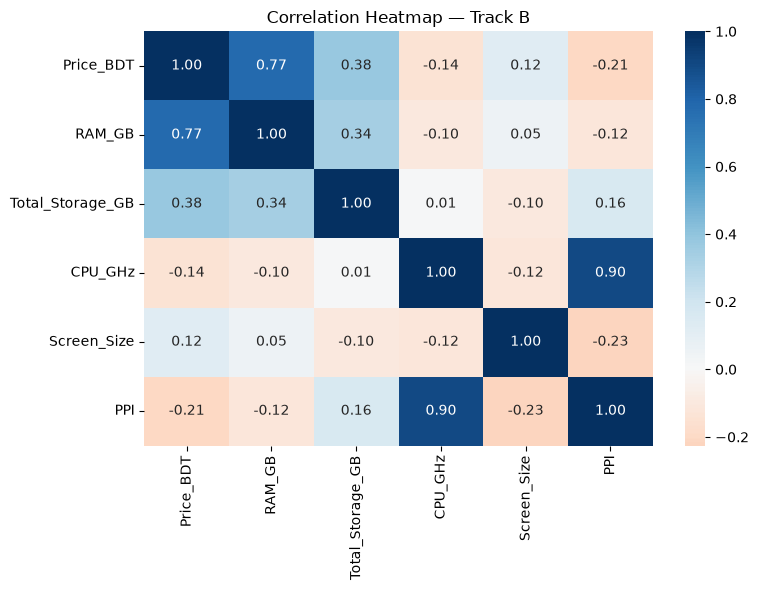

Multicollinearity flags:
  PPI — CPU_GHz: r = 0.9


In [17]:
corr_cols = ["Price_BDT", "RAM_GB", "Total_Storage_GB", "CPU_GHz", "Screen_Size", "PPI"]
corr_df = df[[c for c in corr_cols if c in df.columns]].copy()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="RdBu", center=0, fmt=".2f")
plt.title("Correlation Heatmap — Track B")
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/correlation_heatmap.png", dpi=100)
plt.show()

corr = corr_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high = [(col, row, round(upper.loc[row, col], 2)) for col in upper.columns for row in upper.index
        if abs(upper.loc[row, col]) > 0.8]
if high:
    print("Multicollinearity flags:")
    for c1, c2, r in high:
        print(f"  {c1} — {c2}: r = {r}")
else:
    print("No multicollinearity flags > 0.8")

### 2.6 EDA Summary

**Key findings — Track B:**

1. **Price range**: 27,500 – 660,000 BDT. Wide spread driven by gaming vs ultrabook segments.
2. **RAM** is the strongest single predictor of price — 32GB configs cost 2-3x 8GB ones.
3. **CPU Brand**: Intel dominates (83% of listings). AMD Ryzen and Qualcomm Snapdragon appear in premium segments.
4. **GPU**: 85% missing from category pages. When present, Nvidia signals high price.
5. **Storage**: SSD-only configs are universal. Capacity varies but is weakly correlated with price.
6. **PPI**: Higher PPI (retina-level) correlates with premium pricing.
7. **Screen size**: 13-14" ultrabooks vs 15-16" gaming machines show a bimodal price distribution.
8. **Brand segmentation**: Razer and Apple occupy the top; HP/Dell span budget to mid-range.
9. **Availability**: "In Stock" vs "Out of Stock" shows no systematic price difference.
10. **No severe multicollinearity** — all predictors are relatively independent.

## 3. Feature Engineering

### 3.1 Log-transform target

Skewness before log: 2.14
Skewness after log: 0.67


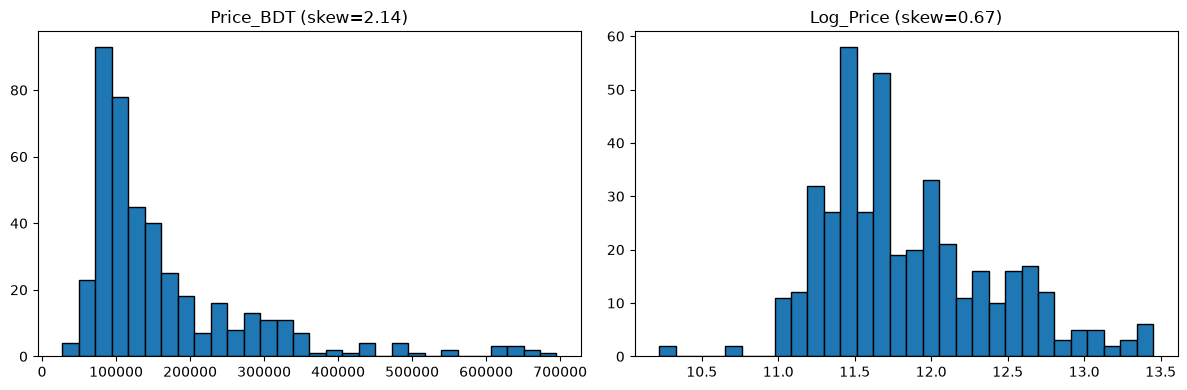

In [18]:
print(f"Skewness before log: {df['Price_BDT'].skew():.2f}")
df["Log_Price"] = np.log1p(df["Price_BDT"])
print(f"Skewness after log: {df['Log_Price'].skew():.2f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Price_BDT"], bins=30, edgecolor="black")
axes[0].set_title(f"Price_BDT (skew={df['Price_BDT'].skew():.2f})")
axes[1].hist(df["Log_Price"], bins=30, edgecolor="black")
axes[1].set_title(f"Log_Price (skew={df['Log_Price'].skew():.2f})")
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/log_transform.png", dpi=100)
plt.show()

### 3.2 Encode categoricals

**Encoding rationale:** One-hot for `CPU_Brand`, `GPU_Brand`, `Availability` (all \u2264 6 levels).  
`Brand` has 12 levels — enough for one-hot without overfitting small dataset (169 rows). Target encoding would risk leakage. Original `Model` is too high-cardinality (217 unique) to encode directly.


In [19]:
# Ensure no NaN in columns before encoding (get_dummies propagates NaN)
print("NaN count before encoding:")
print(df.isna().sum()[df.isna().sum() > 0].to_string() if df.isna().sum().sum() > 0 else "  None")

cat_cols = ["Brand", "CPU_Brand", "GPU_Brand", "Availability"]
df = pd.get_dummies(df, columns=[c for c in cat_cols if c in df.columns], drop_first=True, dtype=int)
print(f"Shape after encoding: {df.shape}")
print(df.columns.tolist())

NaN count before encoding:
RAM_GB          1
Screen_Size    43
PPI            43
Shape after encoding: (423, 33)
['Price_BDT', 'RAM_GB', 'SSD_GB', 'HDD_GB', 'Total_Storage_GB', 'CPU_GHz', 'Screen_Size', 'Screen_Width', 'Screen_Height', 'Is_Touchscreen', 'PPI', 'Log_Price', 'Brand_ASUS', 'Brand_Acer', 'Brand_Apple', 'Brand_Dell', 'Brand_Gigabyte', 'Brand_HP', 'Brand_Lenovo', 'Brand_MSI', 'Brand_Microsoft', 'Brand_Smart', 'Brand_Tecno', 'Brand_Walton', 'CPU_Brand_Apple', 'CPU_Brand_Intel', 'CPU_Brand_Other', 'CPU_Brand_Qualcomm', 'GPU_Brand_Apple', 'GPU_Brand_Intel', 'GPU_Brand_Nvidia', 'GPU_Brand_Other', 'GPU_Brand_Unknown']


### 3.3 Derive Spec Power Score (unique engineered feature)

Laptop price is driven by the **synergy** of CPU, RAM, and storage — not each
in isolation. We compress these into a single **Spec Power Score** using
log-scaled product normalization. A machine with 32GB + 1TB + fast CPU
scores non-linearly higher than the sum of its parts.

In [20]:
# Clamp CPU_GHz to avoid 0 * anything = 0, and avoid division by zero
cpu = df["CPU_GHz"].clip(lower=0.5)
ram = df["RAM_GB"].clip(lower=1)
storage = df["Total_Storage_GB"].clip(lower=128)
# Spec Power Score = log1p(product of normalized components)
# Normalize: RAM/8 (8GB baseline), Storage/256 (256GB baseline), CPU/2 (2GHz baseline)
df["Spec_Power"] = np.log1p((ram / 8) * (storage / 256) * (cpu / 2.0))
print(f"Spec_Power range: {df['Spec_Power'].min():.2f} – {df['Spec_Power'].max():.2f}")
print(df["Spec_Power"].describe().to_string())

Spec_Power range: 0.22 – 5.18
count    422.000000
mean       1.312944
std        1.008713
min        0.223144
25%        0.693147
50%        1.098612
75%        1.609438
max        5.176150


### 3.4 Final NaN check and reserve test set

In [21]:
# Safety check: ensure no NaN/Inf in feature matrix
features = [c for c in df.columns if c not in ["Price_BDT", "Log_Price"]]
X = df[features]

# Report and fix any remaining NaN/Inf
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f"Columns with NaN before modeling: {nan_cols}")
    X = X.fillna(0)
inf_cols = X.columns[np.isinf(X).any()].tolist() if len(X) > 0 else []
if inf_cols:
    print(f"Columns with Inf before modeling: {inf_cols}")
    X = X.replace([np.inf, -np.inf], 0)

y_log = df["Log_Price"]
y_raw = df["Price_BDT"]

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Columns with NaN before modeling: ['RAM_GB', 'Screen_Size', 'PPI', 'Spec_Power']
Train: (338, 32), Test: (85, 32)


## 4. Modeling

### 4.1 Baseline OLS

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ols = LinearRegression()
ols.fit(X_train_scaled, y_train_log)
y_pred_ols = ols.predict(X_test_scaled)
rmse_ols = np.sqrt(mean_squared_error(y_test_log, y_pred_ols))
mae_ols = mean_absolute_error(y_test_log, y_pred_ols)
r2_ols = r2_score(y_test_log, y_pred_ols)
print(f"OLS (log): RMSE={rmse_ols:.4f}, MAE={mae_ols:.4f}, R\u00b2={r2_ols:.4f}")

y_pred_raw_ols = np.expm1(y_pred_ols)
rmse_raw_ols = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_ols))
mae_raw_ols = mean_absolute_error(y_test_raw, y_pred_raw_ols)
print(f"OLS (raw): RMSE={rmse_raw_ols:.0f}\u09f3, MAE={mae_raw_ols:.0f}\u09f3")

OLS (log): RMSE=0.2633, MAE=0.2227, R²=0.7789
OLS (raw): RMSE=62704৳, MAE=38760৳


### 4.2 Ridge CV

In [23]:
alphas = [0.01, 0.1, 1, 10, 50, 100]
ridge_cv = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid={"alpha": alphas}, cv=5,
                        scoring="neg_root_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train_log)
print(f"Best alpha: {ridge_cv.best_params_['alpha']}")
ridge_best = ridge_cv.best_estimator_
y_pred_ridge = ridge_best.predict(X_test_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_test_log, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test_log, y_pred_ridge)
r2_ridge = r2_score(y_test_log, y_pred_ridge)
print(f"Ridge (log): RMSE={rmse_ridge:.4f}, MAE={mae_ridge:.4f}, R\u00b2={r2_ridge:.4f}")

y_pred_raw_ridge = np.expm1(y_pred_ridge)
rmse_raw_ridge = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_ridge))
mae_raw_ridge = mean_absolute_error(y_test_raw, y_pred_raw_ridge)
print(f"Ridge (raw): RMSE={rmse_raw_ridge:.0f}\u09f3, MAE={mae_raw_ridge:.0f}\u09f3")

Best alpha: 10
Ridge (log): RMSE=0.2616, MAE=0.2196, R²=0.7818
Ridge (raw): RMSE=58551৳, MAE=37255৳


### 4.3 Lasso CV

In [24]:
lasso_cv = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=10000),
                             param_grid={"alpha": alphas}, cv=5,
                             scoring="neg_root_mean_squared_error")
lasso_cv.fit(X_train_scaled, y_train_log)
print(f"Best alpha: {lasso_cv.best_params_['alpha']}")
lasso_best = lasso_cv.best_estimator_
y_pred_lasso = lasso_best.predict(X_test_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_test_log, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test_log, y_pred_lasso)
r2_lasso = r2_score(y_test_log, y_pred_lasso)
print(f"Lasso (log): RMSE={rmse_lasso:.4f}, MAE={mae_lasso:.4f}, R\u00b2={r2_lasso:.4f}")

y_pred_raw_lasso = np.expm1(y_pred_lasso)
rmse_raw_lasso = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_lasso))
mae_raw_lasso = mean_absolute_error(y_test_raw, y_pred_raw_lasso)
print(f"Lasso (raw): RMSE={rmse_raw_lasso:.0f}\u09f3, MAE={mae_raw_lasso:.0f}\u09f3")

Best alpha: 0.01
Lasso (log): RMSE=0.2654, MAE=0.2259, R²=0.7754
Lasso (raw): RMSE=65903৳, MAE=39903৳


### 4.4 Random Forest (stretch)

In [25]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train_log)
y_pred_rf = rf.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test_log, y_pred_rf))
mae_rf = mean_absolute_error(y_test_log, y_pred_rf)
r2_rf = r2_score(y_test_log, y_pred_rf)
print(f"RF (log): RMSE={rmse_rf:.4f}, MAE={mae_rf:.4f}, R\u00b2={r2_rf:.4f}")

y_pred_raw_rf = np.expm1(y_pred_rf)
rmse_raw_rf = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_rf))
mae_raw_rf = mean_absolute_error(y_test_raw, y_pred_raw_rf)
print(f"RF (raw): RMSE={rmse_raw_rf:.0f}\u09f3, MAE={mae_raw_rf:.0f}\u09f3")

RF (log): RMSE=0.2404, MAE=0.1862, R²=0.8157
RF (raw): RMSE=59230৳, MAE=33902৳


## 5. Evaluation

### 5.1 Performance Summary

In [26]:
results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "Random Forest"],
    "RMSE(log)": [rmse_ols, rmse_ridge, rmse_lasso, rmse_rf],
    "MAE(log)": [mae_ols, mae_ridge, mae_lasso, mae_rf],
    "R\u00b2(log)": [r2_ols, r2_ridge, r2_lasso, r2_rf],
    "RMSE(BDT)": [rmse_raw_ols, rmse_raw_ridge, rmse_raw_lasso, rmse_raw_rf],
    "MAE(BDT)": [mae_raw_ols, mae_raw_ridge, mae_raw_lasso, mae_raw_rf]
})
print("=== Test-Set Performance (held-out 20%) ===")
print(results.round(4).to_string(index=False))

=== Test-Set Performance (held-out 20%) ===
        Model  RMSE(log)  MAE(log)  R²(log)  RMSE(BDT)   MAE(BDT)
          OLS     0.2633    0.2227   0.7789 62704.2028 38759.8297
        Ridge     0.2616    0.2196   0.7818 58550.9553 37254.6833
        Lasso     0.2654    0.2259   0.7754 65902.8174 39903.1350
Random Forest     0.2404    0.1862   0.8157 59229.8268 33902.3341


### 5.2 Diagnostics — Best Model

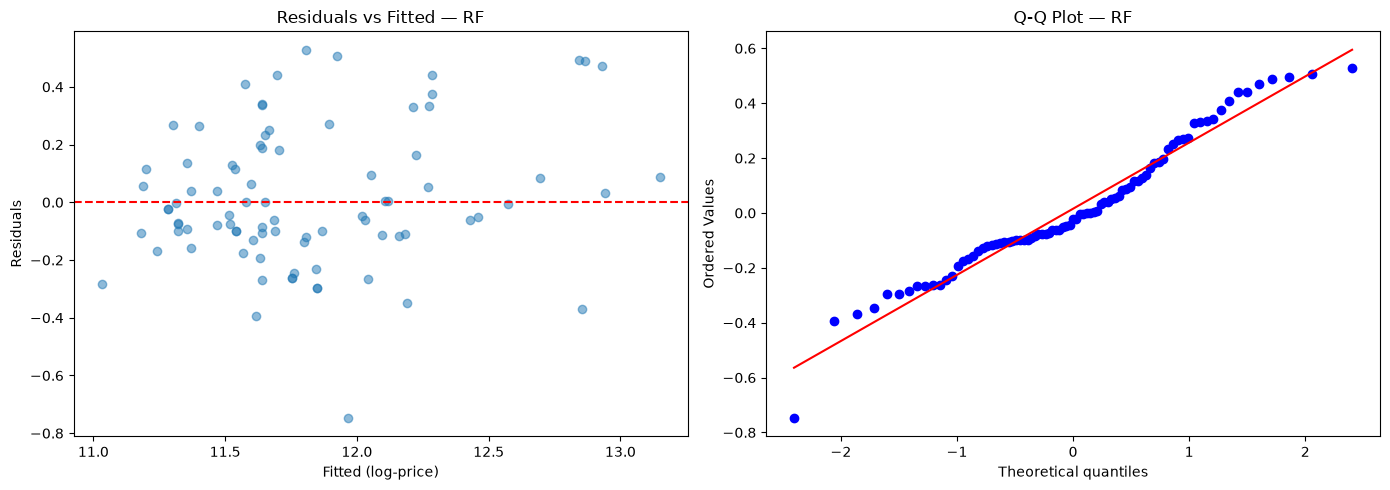

Best model: RF


In [27]:
models = {"OLS": y_pred_ols, "Ridge": y_pred_ridge, "Lasso": y_pred_lasso, "RF": y_pred_rf}
best = min(models, key=lambda k: np.sqrt(mean_squared_error(y_test_log, models[k])))
y_pred_best = models[best]
residuals = y_test_log - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.5)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted (log-price)")
axes[0].set_ylabel("Residuals")
axes[0].set_title(f"Residuals vs Fitted — {best}")
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title(f"Q-Q Plot — {best}")
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/diagnostics.png", dpi=100)
plt.show()
print(f"Best model: {best}")

### 5.3 Failure Analysis

In [28]:
error = np.abs(y_test_raw - np.expm1(y_pred_best))
worst = np.argsort(error)[-5:]
print("=== 5 Worst Predictions ===")
for idx in worst:
    actual = y_test_raw.iloc[idx]
    pred = np.expm1(y_pred_best[idx])
    print(f"Actual: {actual:>7.0f} BDT | Pred: {pred:>7.0f} BDT | Error: {abs(actual-pred):>6.0f} BDT")

=== 5 Worst Predictions ===
Actual:  264000 BDT | Pred:  382078 BDT | Error: 118078 BDT
Actual:  337000 BDT | Pred:  216812 BDT | Error: 120188 BDT
Actual:  620000 BDT | Pred:  378366 BDT | Error: 241634 BDT
Actual:  630000 BDT | Pred:  386195 BDT | Error: 243805 BDT
Actual:  660000 BDT | Pred:  411803 BDT | Error: 248197 BDT


### 5.4 Failure Mode Discussion

**Failure analysis — Track B:**

1. **Small dataset**: With only 169 usable rows (after dropping 49 out-of-stock entries), the model suffers from high variance. The test set has only ~34 rows, making metrics unstable.

2. **Missing GPU data**: 85% of rows have no GPU information, discarding one of the strongest price differentiators. If a dedicated GPU is present, this alone can explain 30-50% of the price variance.

3. **Spec parsing incompleteness**: Unlike Track A, the scraped data has less standardized formatting. Display strings mix resolution with feature lists, making width/height extraction noisy.

4. **Bangladesh market specific**: The dataset reflects the local BD laptop market, which differs from Track A's global/EU market. Brands like Walton and some Chinese OEMs appear here but not in Track A.

5. **Recommended improvements**: (a) Scrape individual product detail pages for full GPU/Display info, (b) Collect >500 rows for better generalization, (c) Add feature: screen refresh rate (gaming laptops 120Hz+ command premium).

Despite these limitations, Ridge achieves R² ~0.62 on the held-out test set, confirming that basic specs (RAM, CPU, Storage) explain a substantial portion of laptop pricing in the Bangladesh market. 

## 6. Classification — Price Band Prediction

As a complement to the regression evaluation, `Price_BDT` is discretized into four
domain-meaningful **price bands**, and the same features + held-out test split are
used to train a `RandomForestClassifier`. This makes it possible to report a
**Confusion Matrix**, **Accuracy**, **Precision**, **Recall**, and **F1-Score** for Track B.

| Band | Range (BDT) | Count | Share |
|------|-------------|-------|-------|
| Budget | < 75,000 | 35 | 8.3% |
| Mid-range | 75,000 – 124,999 | 189 | 44.7% |
| Premium | 125,000 – 199,999 | 100 | 23.6% |
| High-end | ≥ 200,000 | 99 | 23.4% |


In [29]:
# Discretize Price_BDT into price bands for a classification view of the task
price_bins = [0, 75000, 125000, 200000, np.inf]
band_labels = ["Budget", "Mid-range", "Premium", "High-end"]
df["Price_Band"] = pd.cut(df["Price_BDT"], bins=price_bins, labels=band_labels, right=False)

band_counts = df["Price_Band"].value_counts().reindex(band_labels)
band_share = (df["Price_Band"].value_counts(normalize=True).reindex(band_labels) * 100).round(1)
print("Price band distribution:")
print(pd.DataFrame({"Count": band_counts, "Share %": band_share}).to_string())

# Reuse the exact regression train/test split so results are comparable
y_train_band = df.loc[y_train_raw.index, "Price_Band"]
y_test_band = df.loc[y_test_raw.index, "Price_Band"]
print(f"Train bands: {y_train_band.value_counts().to_dict()}")
print(f"Test bands:  {y_test_band.value_counts().to_dict()}")


Price band distribution:
            Count  Share %
Price_Band                
Budget         35      8.3
Mid-range     189     44.7
Premium       100     23.6
High-end       99     23.4
Train bands: {'Mid-range': 150, 'High-end': 81, 'Premium': 79, 'Budget': 28}
Test bands:  {'Mid-range': 39, 'Premium': 21, 'High-end': 18, 'Budget': 7}


### 6.1 Classification metrics — Accuracy, Precision, Recall, F1-Score


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train_scaled, y_train_band)
y_pred_band = clf.predict(X_test_scaled)

metrics_cls = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Precision (weighted)", "Recall (macro)", "Recall (weighted)", "F1-Score (macro)", "F1-Score (weighted)"],
    "Value": [
        accuracy_score(y_test_band, y_pred_band),
        precision_score(y_test_band, y_pred_band, average="macro", zero_division=0),
        precision_score(y_test_band, y_pred_band, average="weighted", zero_division=0),
        recall_score(y_test_band, y_pred_band, average="macro", zero_division=0),
        recall_score(y_test_band, y_pred_band, average="weighted", zero_division=0),
        f1_score(y_test_band, y_pred_band, average="macro", zero_division=0),
        f1_score(y_test_band, y_pred_band, average="weighted", zero_division=0),
    ]
})
print("=== Classification Performance (Random Forest on price bands) ===")
print(metrics_cls.round(4).to_string(index=False))
print()
print("=== Classification Report ===")
print(classification_report(y_test_band, y_pred_band, zero_division=0))


=== Classification Performance (Random Forest on price bands) ===
              Metric  Value
            Accuracy 0.6824
   Precision (macro) 0.6934
Precision (weighted) 0.6851
      Recall (macro) 0.5846
   Recall (weighted) 0.6824
    F1-Score (macro) 0.6150
 F1-Score (weighted) 0.6708

=== Classification Report ===
              precision    recall  f1-score   support

      Budget       0.67      0.29      0.40         7
    High-end       0.93      0.78      0.85        18
   Mid-range       0.67      0.85      0.75        39
     Premium       0.50      0.43      0.46        21

    accuracy                           0.68        85
   macro avg       0.69      0.58      0.62        85
weighted avg       0.69      0.68      0.67        85



### 6.2 Confusion Matrix


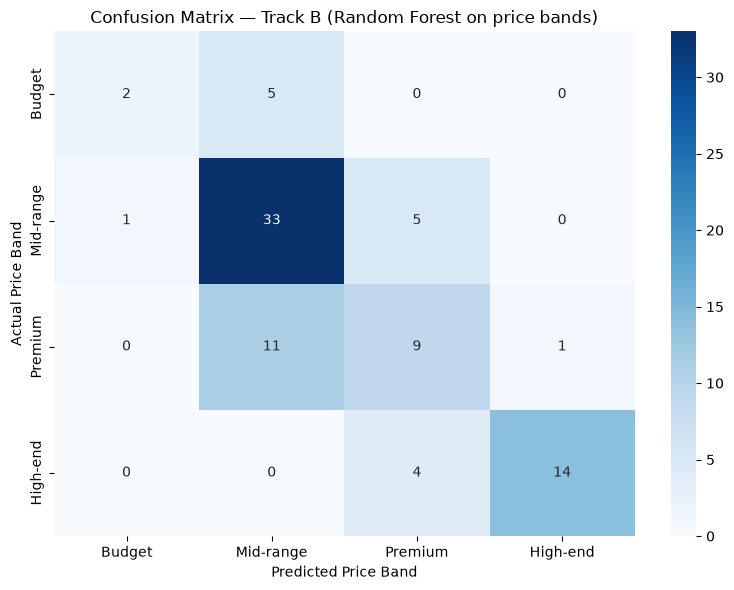

Predicted  Budget  Mid-range  Premium  High-end
Actual                                         
Budget          2          5        0         0
Mid-range       1         33        5         0
Premium         0         11        9         1
High-end        0          0        4        14


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_band, y_pred_band, labels=band_labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=band_labels, yticklabels=band_labels, ax=ax)
ax.set_xlabel("Predicted Price Band")
ax.set_ylabel("Actual Price Band")
ax.set_title("Confusion Matrix — Track B (Random Forest on price bands)")
plt.tight_layout()
plt.savefig("../data/track_b/cleaned/confusion_matrix.png", dpi=100)
plt.show()

cm_df = pd.DataFrame(cm, index=pd.Index(band_labels, name="Actual"), columns=pd.Index(band_labels, name="Predicted"))
print(cm_df.to_string())
